In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

pd.options.display.max_columns = None

In [28]:
load_dotenv()
csv_path = os.getenv('csv_path')
df = pd.read_csv(csv_path)

In [29]:
df.shape

(122400, 12)

In [30]:
df

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388
...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,280.986396
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700.0,NaN,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [32]:
df.isnull().sum()*100/df.shape[0]

video_id                0.000000
date                    0.000000
views                   0.000000
likes                   4.997549
comments                4.993464
watch_time_minutes      4.987745
video_length_minutes    0.000000
subscribers             0.000000
category                0.000000
device                  0.000000
country                 0.000000
ad_revenue_usd          0.000000
dtype: float64

In [33]:
for col in df.columns:
    print(f"{col} : {df[col].nunique()}")

video_id : 5000
date : 365
views : 736
likes : 1855
comments : 466
watch_time_minutes : 114000
video_length_minutes : 120000
subscribers : 113254
category : 6
device : 4
country : 6
ad_revenue_usd : 120000


In [34]:
df.duplicated().sum()

np.int64(2400)

In [35]:
df.drop_duplicates(inplace=True)

In [41]:
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
mean,9999.832333,1099.705792,274.332350,37539.823485,16.017910,502291.970050,252.711361
std,99.918405,506.372185,126.461529,12658.957710,8.084928,288364.967705,61.954125
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,673.000000,168.000000,26949.914101,9.005928,252641.500000,199.892158
50%,10000.000000,1102.000000,274.000000,37522.221205,16.009269,503633.500000,252.678607
75%,10067.000000,1524.000000,381.000000,48209.880123,23.026064,752386.250000,305.613497
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [42]:
df.describe(include=object)

,video_id,date,category,device,country
count,120000,120000,120000,120000,120000
unique,5000,365,6,4,6
top,vid_3033,2025-04-03 10:50:40.993199,Education,TV,CA
freq,46,378,20123,30086,20198


In [36]:
df.corr(numeric_only=True)

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
views,1.000000,0.015607,0.018597,0.026737,0.001171,0.000750,0.037942
likes,0.015607,1.000000,-0.002138,0.002864,0.001817,0.003622,0.146269
comments,0.018597,-0.002138,1.000000,-0.000749,-0.002233,-0.001564,0.034494
watch_time_minutes,0.026737,0.002864,-0.000749,1.000000,-0.000398,0.004734,0.988869
video_length_minutes,0.001171,0.001817,-0.002233,-0.000398,1.000000,0.002015,0.000364
subscribers,0.000750,0.003622,-0.001564,0.004734,0.002015,1.000000,0.005065
ad_revenue_usd,0.037942,0.146269,0.034494,0.988869,0.000364,0.005065,1.000000


<Axes: >

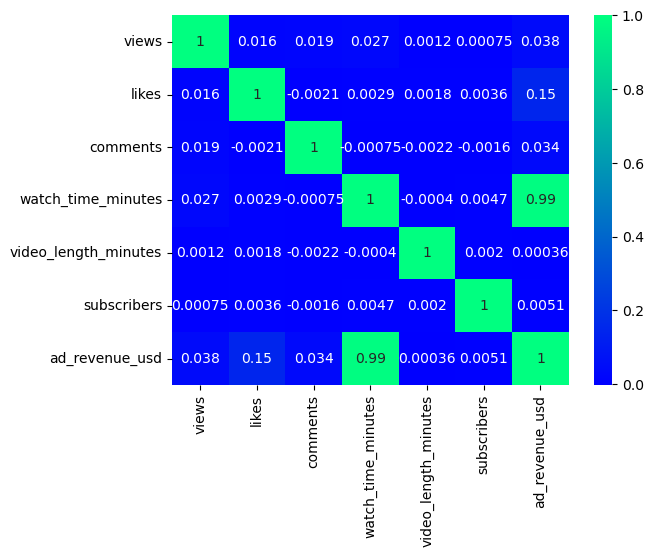

In [37]:
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap='winter')

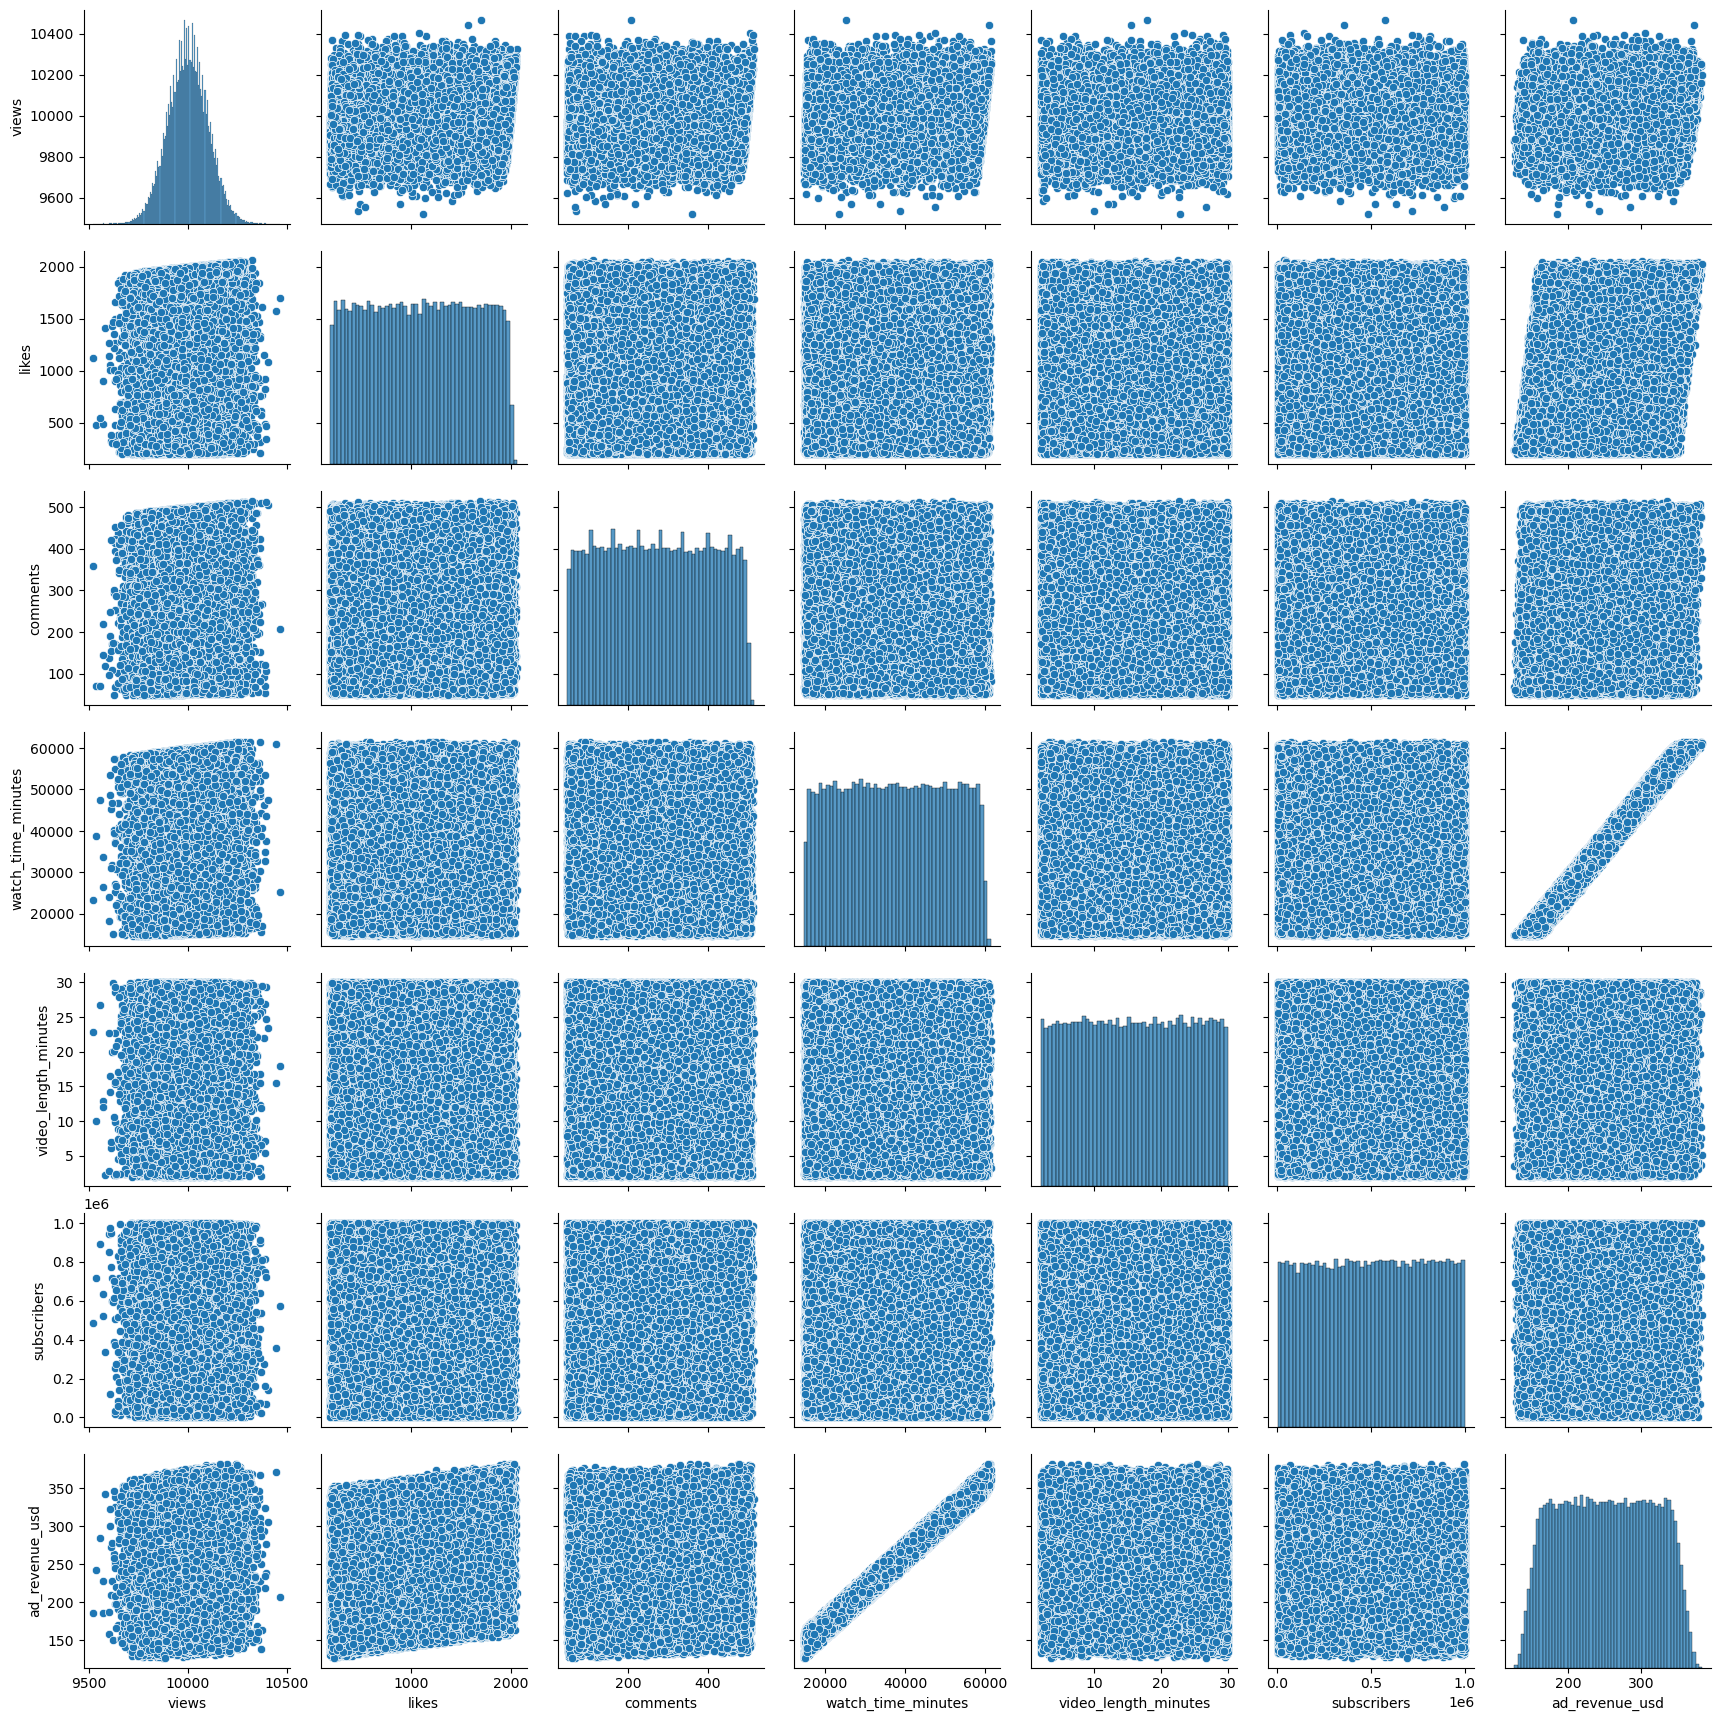

In [14]:
sns.pairplot(df)

In [43]:
pd.crosstab(df['category'],df['country'])

country,AU,CA,DE,IN,UK,US
category,,,,,,
Education,3308,3340,3439,3406,3319,3311
Entertainment,3328,3378,3317,3340,3370,3292
Gaming,3367,3457,3338,3247,3334,3231
Lifestyle,3257,3295,3336,3324,3328,3245
Music,3375,3354,3396,3317,3303,3320
Tech,3276,3374,3334,3522,3239,3283


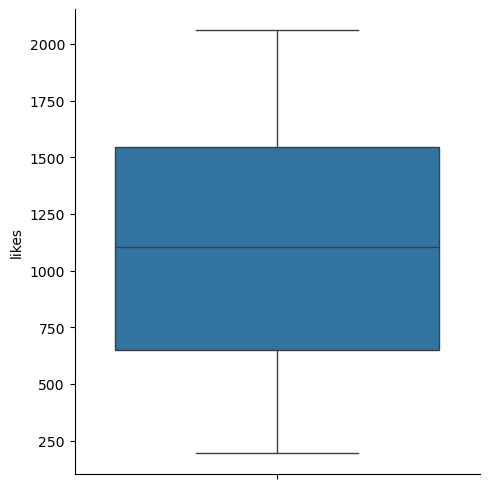

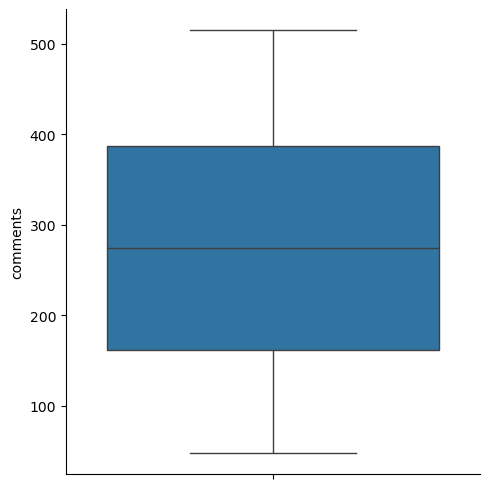

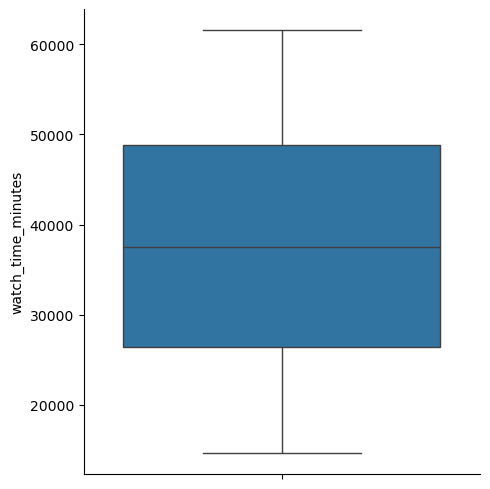

In [38]:
sns.catplot(df['likes'], kind='box' )
sns.catplot(df['comments'], kind='box' )
sns.catplot(df['watch_time_minutes'], kind='box' )

In [39]:
from sklearn.impute import SimpleImputer

imp_cols = ['likes','comments','watch_time_minutes']
imputer = SimpleImputer(strategy='median')

df[imp_cols] = imputer.fit_transform(df[imp_cols])

<Axes: xlabel='ad_revenue_usd', ylabel='Count'>

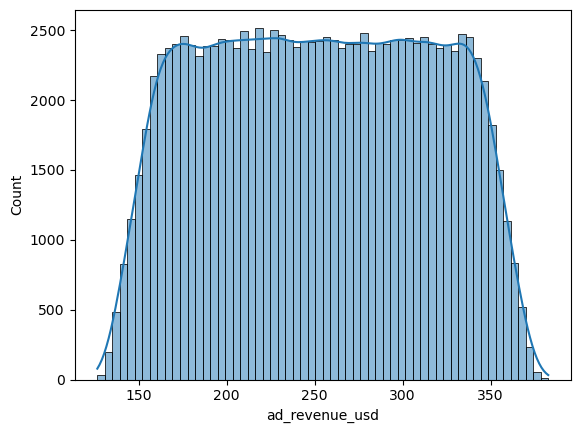

In [40]:
sns.histplot(df['ad_revenue_usd'], kde=True)

In [22]:
df.to_csv('cleaned_data.csv',index=False)

In [23]:
# Key Findings:

# 1. dropped duplicate rows.
# 2. approx 5% missing val in likes, comments, watch_time_minutes - filled with median.
# 3. strong co-relation between watchtime and ad_revenue ( target col ).
# 4. likes got moderate co-relation to target col, while likes, comments, subscribes have weak relation.
# 5. The target variable distribution appeared reasonably continuous and suitable for regression modeling.